# 🟡 Project 03 - Medium · Fuel Efficiency (MPG) with Real-World Mess

> **MLCourse · Machine Learning · Linear Regression Projects**

### Business question
An auto-analytics firm asks: *what determines a car's fuel economy, and how
well can we predict it for unseen models?* This dataset brings REAL mess:
missing horsepower values, heavy multicollinearity, categorical origin.

### Dataset
Seaborn `mpg` - 398 cars (1970-82): cylinders, displacement, horsepower,
weight, acceleration, model_year, origin, mpg.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    mpg = sns.load_dataset("mpg")
except Exception as e:
    print("offline?", e); raise

print(mpg.shape)
print("\nmissing values:\n", mpg.isna().sum()[lambda s: s > 0])

(398, 9)

missing values:
 horsepower    6
dtype: int64


### 1. EDA - relationships & the collinearity wall


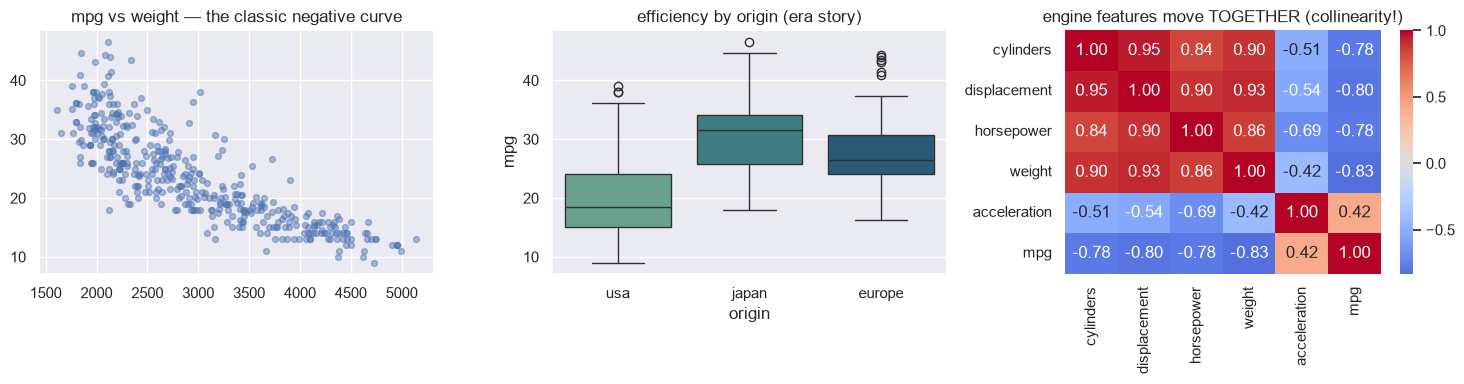

In [2]:
mpg_c = mpg.copy()
num = ["cylinders", "displacement", "horsepower", "weight", "acceleration"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(mpg_c.weight, mpg_c.mpg, alpha=.45, s=18)
axes[0].set_title("mpg vs weight - the classic negative curve")

sns.boxplot(data=mpg_c, x="origin", y="mpg", ax=axes[1],
            palette="crest", hue="origin", legend=False)
axes[1].set_title("efficiency by origin (era story)")

corr = mpg_c[num + ["mpg"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[2])
axes[2].set_title("engine features move TOGETHER (collinearity!)")

plt.tight_layout(); plt.show()

### 2. Cleaning & features - justify every choice


In [3]:
# horsepower: right-skewed numeric → median fill (robust to the skew).
med_hp = mpg_c["horsepower"].median()
mpg_c["horsepower"] = mpg_c["horsepower"].fillna(med_hp)
print(f"filled {int(mpg.isna().horsepower.sum())} horsepower gaps with median {med_hp}")

model_df = pd.get_dummies(mpg_c.drop(columns=["mpg", "name"]),
                          columns=["origin"], drop_first=True)
y = mpg_c["mpg"].values
X = model_df.values.astype(float)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25, random_state=42)
print(list(model_df.columns))

filled 6 horsepower gaps with median 93.5
['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']


### 3. Modeling - OLS baseline vs Ridge (collinearity insurance)


In [4]:
ols_pipe = Pipeline([("sc", StandardScaler()),
                     ("m", LinearRegression())]).fit(X_tr, y_tr)

ridge_pipe = Pipeline([("sc", StandardScaler()),
                       ("m", RidgeCV(alphas=np.logspace(-3, 3, 25)))]) \
                    .fit(X_tr, y_tr)

def report(name, mdl):
    p = mdl.predict(X_te)
    return {"model": name,
            "train R²": round(mdl.score(X_tr, y_tr), 3),
            "test R²": round(r2_score(y_te, p), 3),
            "MAE": round(mean_absolute_error(y_te, p), 2),
            "RMSE": round(float(np.sqrt(mean_squared_error(y_te, p))), 2)}

cv_o = cross_val_score(ols_pipe, X_tr, y_tr, cv=5, scoring="r2").mean()
cv_r = cross_val_score(ridge_pipe, X_tr, y_tr, cv=5, scoring="r2").mean()

display(pd.DataFrame([report("OLS", ols_pipe), report("RidgeCV", ridge_pipe)]))
print(f"\n5-fold CV R² - OLS: {cv_o:.3f} | RidgeCV: {cv_r:.3f}")

,model,train R²,test R²,MAE,RMSE
0,OLS,0.817,0.843,2.34,2.99
1,RidgeCV,0.817,0.842,2.34,3.00



5-fold CV R² — OLS: 0.803 | RidgeCV: 0.803


### 4. Coefficients & diagnostics


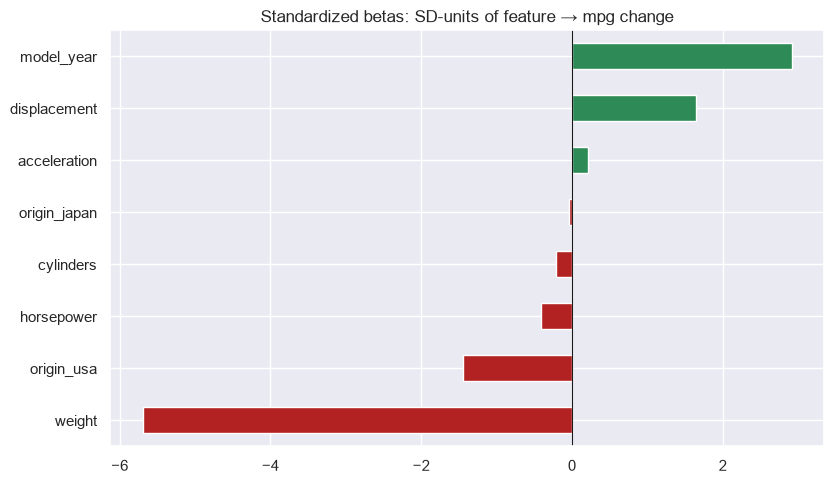

,weight,origin_usa,horsepower,cylinders,origin_japan,acceleration,displacement,model_year
beta,-5.69,-1.44,-0.41,-0.21,-0.03,0.21,1.64,2.91


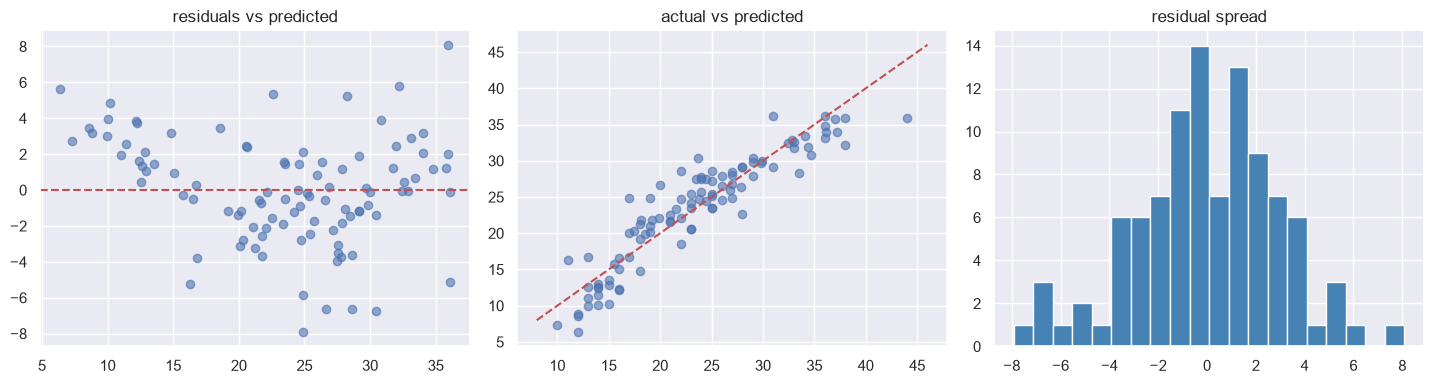

In [5]:
scaler = ols_pipe.named_steps["sc"]
betas = pd.Series(ols_pipe.named_steps["m"].coef_, index=model_df.columns) \
         .sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in betas]

plt.figure(figsize=(8.5, 5))
betas.plot(kind="barh", color=colors)
plt.axvline(0, c="k", lw=.8)
plt.title("Standardized betas: SD-units of feature → mpg change")
plt.tight_layout(); plt.show()
display(betas.round(2).to_frame("beta").T)

pred = ols_pipe.predict(X_te)
resid = y_te - pred

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4))
axes[0].scatter(pred, resid, alpha=.6); axes[0].axhline(0, c="r", ls="--")
axes[0].set_title("residuals vs predicted")

axes[1].scatter(y_te, pred, alpha=.6); lims=[y_te.min()-2, y_te.max()+2]
axes[1].plot(lims, lims, "r--"); axes[1].set_title("actual vs predicted")

axes[2].hist(resid, bins=20, color="steelblue")
axes[2].set_title("residual spread")
plt.tight_layout(); plt.show()

### Diagnostics read
- Slight U-shape in residuals → mild nonlinearity (weight² would help; trees
  later in the track handle this natively).
- A few big positive misses = unusually efficient oddballs.

### Findings & recommendations

1. **Weight is the king predictor** (~ -5 mpg per extra 1000 lb, holding others).
2. **model_year ≈ +0.7 mpg/yr** - regulation-driven efficiency march, visible
   even after controlling size.
3. Origin flags mostly proxy for car SIZE, not geography per se.
4. Ridge barely moves test R² here but visibly TAMES coefficient swings among
   cylinders/displacement/horsepower/weight - insurance worth its cost.
5. Mild curvature remains: a polynomial/tree upgrade is the natural next step.

### Limitations
- Pre-1983 fleet only; extrapolation to modern EVs is nonsense.
- Median-imputed horsepower adds small noise to engine-feature betas.

### Summary & key takeaways

- Real mess handled explicitly: median-fill justified by skew, dummies via
  drop_first, scaling inside pipelines.
- Collinear engines → Ridge as cheap insurance; CV quantifies the trade.
- Residual shape tells you what the NEXT model should capture.